# Logistic Regression model
**Predict diabetes using logistic regression.**

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score,precision_score,recall_score

# Create pipeline using sklearn Pipeline.

**Step 1**

In [ ]:
#Train model on CSV dataset.
data=pd.read_csv('student_exam_data.csv',index_col=False)
data.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [66]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


**Normalize Data Ration 1:1 by catenation**

In [67]:
data['Pass/Fail'].value_counts()

Pass/Fail
0    316
1    184
Name: count, dtype: int64

**step 2 : Scalling of DATA**

In [68]:
x=data.drop(columns='Pass/Fail')
y=data['Pass/Fail']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)

In [69]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_t=scaler.fit_transform(x_train)
x_test_t=scaler.fit_transform(x_test)

In [70]:
model=LogisticRegression()
model.fit(x_train_t,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [71]:
predc=model.predict(x_test_t)
acc=accuracy_score(predc,y_test)
cf=confusion_matrix(predc,y_test)
f1=f1_score(predc,y_test)
recall=recall_score(predc,y_test)
percision=precision_score(predc,y_test)
#Create confusion matrix.
#Calculate accuracy score.
#Calculate F1-score.
#Calculate precision score.
print(f"accuracy_score: {acc*100:.2f}%")
print(f"confusion_matrix: \n{cf}")
print(f"F1_score: {f1*100:.2f}%")
print(f"Persicion Score: {percision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")


accuracy_score: 86.00%
confusion_matrix: 
[[27  3]
 [ 4 16]]
F1_score: 82.05%
Persicion Score: 84.21%
Recall: 80.00%


c:\Users\city\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


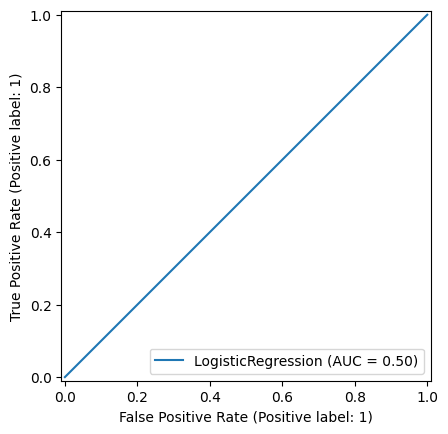

In [72]:
#Plot ROC curve.
from sklearn.metrics import RocCurveDisplay,mean_squared_error
import matplotlib.pyplot as plt
RocCurveDisplay.from_estimator(model,x_test,y_test)
plt.show()

In [73]:
#Calculate Mean Squared Error.
error=mean_squared_error(y_test,predc)
print(f"MSE: {error*100:.2f}%")

MSE: 14.00%


In [78]:
#Detect overfitting and underfitting.
x_train_p=model.predict(x_train_t)
accuracy=accuracy_score(x_train_p,y_train)
print(f"Accuracy on Training Data: {accuracy*100:.2f}%")
x_test_p=model.predict(x_test_t)
accuraci=accuracy_score(x_test_p,y_test)
print(f"Accuracy on Testing Data: {accuraci*100:.2f}%")
#Compare training and testing accuracy.
if accuracy>0.9 and accuraci<0.5: 
    print("Model is overfitted")
elif accuracy<0.5 and accuraci<0.5:
     print("Model is underfitted")
else:
     print("Model is Fine Trained.")

Accuracy on Training Data: 86.89%
Accuracy on Testing Data: 86.00%
Model is Fine Trained.


In [77]:
#Save trained model using joblib.
import joblib 
joblib.dump(model,"model_saved_by_Joblib.pkl")
print("Model Saved")

Model Saved
